In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvZW1tYW51ZWwvRG9jdW1lbnRvcy9Qcm95ZWN0cy9NTF9wcm95ZWN0cy9Qcm95ZWN0by1kZS1maW4tZGUtbW9kdWxvLS0tQWxmYXJvLUJhZGlsbG8tQ3J1ei1QZXJlei1SdXBpdC0tLWNvcGlhU2VsaW0vbWlzX3JlcG9ydGVz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/importlib/_bootstrap.py": 1788106362.2752662, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/importlib/_bootstrap_external.py": 1788106362.279266, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/zipimport.py": 1788106362.3632689, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/codecs.py": 1788106362.2112641, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/encodings/aliases.py": 1788106362.2272646, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/encodings/__init__.py": 1788106362.2272646, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/encodings/utf_8.py": 1788106362.2352648, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/abc.py": 1788106

In [2]:
#| label: setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 10)

# Ajustar esta ruta según el archivo del equipo.
# Si usan la versión .xlsx, cambien esta línea por:
#   df = pd.read_excel("data/raw/MunicipiosSequia.xlsx")
RUTA_DATOS = "../data/raw/MunicipiosSequiaCSV.csv"

In [3]:
#| label: carga

df = pd.read_csv(RUTA_DATOS, encoding="utf-8-sig", low_memory=False)
df.columns = [c.strip() for c in df.columns]

# Columnas de identificación del municipio (no son fechas)
columnas_id = [
    "CVE_CONCATENADA", "CVE_ENT", "CVE_MUN", "NOMBRE_MUN", "ENTIDAD",
    "ORG_CUENCA*", "CLV_OC", "CON_CUENCA", "CVE_CONC",
]
columnas_fecha = [c for c in df.columns if c not in columnas_id]

print(f"Municipios: {df.shape[0]:,}")
print(f"Columnas de identificación: {len(columnas_id)}")
print(f"Columnas de fecha (periodos publicados): {len(columnas_fecha)}")
print(f"Entidades federativas: {df['ENTIDAD'].nunique()}")

Municipios: 2,478
Columnas de identificación: 9
Columnas de fecha (periodos publicados): 435
Entidades federativas: 32


In [4]:
#| label: integridad

duplicados = df["CVE_CONCATENADA"].duplicated().sum()
nulos_id = df[columnas_id].isna().sum().sum()

print(f"Claves de municipio duplicadas: {duplicados}")
print(f"Valores nulos en columnas de identificación: {nulos_id}")

assert duplicados == 0, "Hay CVE_CONCATENADA duplicadas"
assert nulos_id == 0, "Hay nulos en columnas de identificación"

Claves de municipio duplicadas: 0
Valores nulos en columnas de identificación: 0


In [5]:
#| label: fn-parseo

MESES = {
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dic": 12,
}

def parsear_fecha(col_name: str) -> pd.Timestamp:
    """Convierte 'dd-mmm-aa' (español) a Timestamp, p.ej. '15-sep-26' -> 2026-09-15."""
    dia, mes_abr, anio2 = col_name.split("-")
    return pd.Timestamp(year=2000 + int(anio2), month=MESES[mes_abr.lower()], day=int(dia))

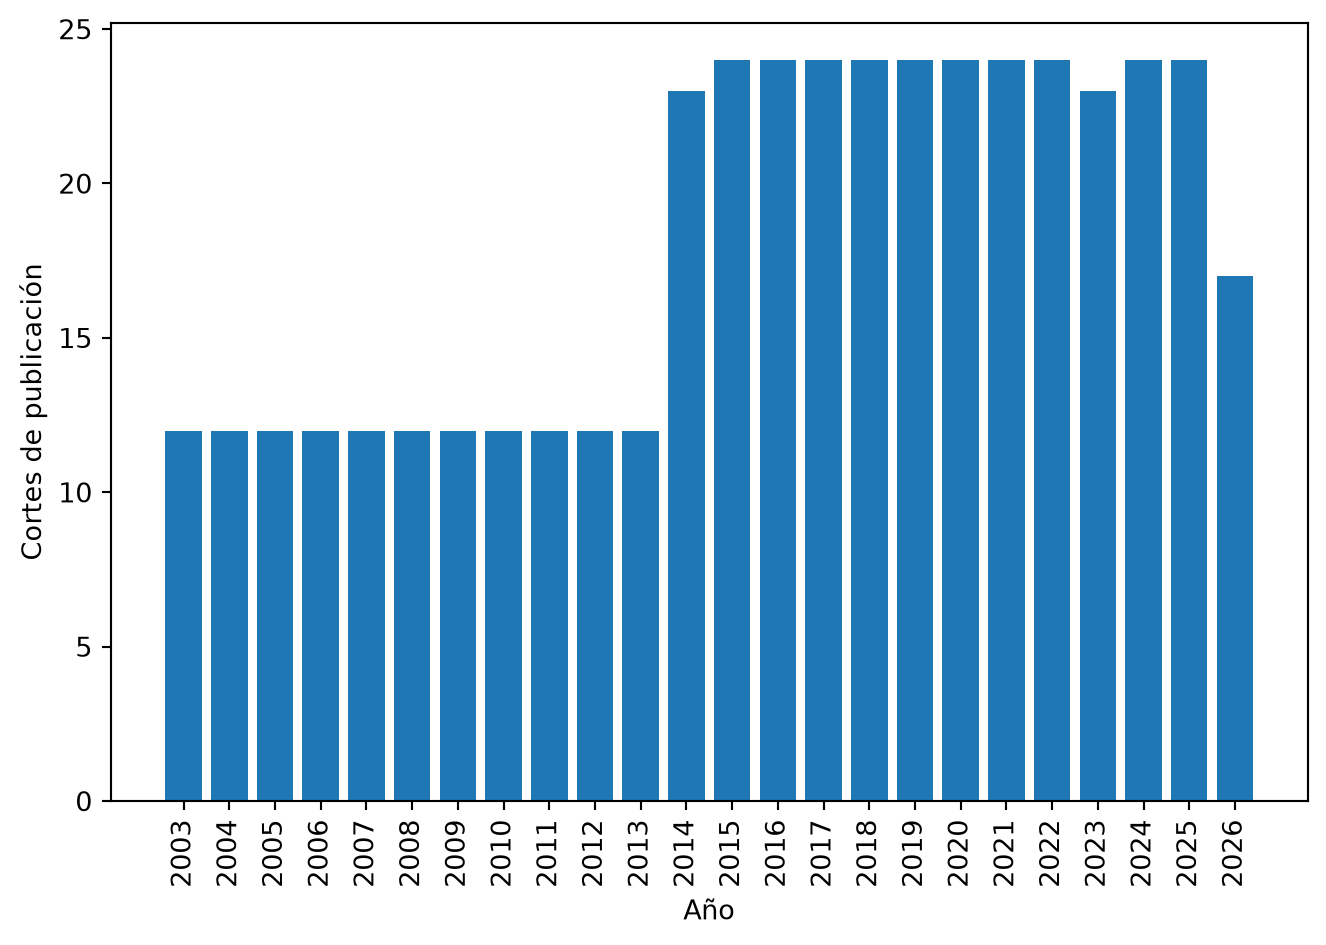

In [6]:
#| label: fig-cobertura-anual
#| fig-cap: Número de cortes de publicación del monitor por año

fechas_cols = pd.Series(columnas_fecha).map(parsear_fecha)
conteo_anual = fechas_cols.dt.year.value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(conteo_anual.index.astype(str), conteo_anual.values)
ax.set_xlabel("Año")
ax.set_ylabel("Cortes de publicación")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [7]:
#| label: cols-2016

fecha_por_columna = dict(zip(columnas_fecha, fechas_cols))
columnas_2016 = [c for c in columnas_fecha if fecha_por_columna[c] >= pd.Timestamp("2016-01-01")]

print(f"Columnas totales: {len(columnas_fecha)}")
print(f"Columnas a partir de 2016 (dataset analítico): {len(columnas_2016)}")
print(f"Columnas descartadas (2003-2015, dataset histórico únicamente): "
      f"{len(columnas_fecha) - len(columnas_2016)}")

Columnas totales: 435
Columnas a partir de 2016 (dataset analítico): 256
Columnas descartadas (2003-2015, dataset histórico únicamente): 179


In [8]:
#| label: mapas-intensidad

intensidad_map = {np.nan: 0, "D0": 1, "D1": 2, "D2": 3, "D3": 4, "D4": 5}
intensidad_labels = {
    0: "Sin sequía",
    1: "D0 Anormalmente seco",
    2: "D1 Sequía moderada",
    3: "D2 Sequía severa",
    4: "D3 Sequía extrema",
    5: "D4 Sequía excepcional",
}

In [9]:
#| label: huecos-publicacion

frac_vacio = df[columnas_fecha].isna().mean()
huecos_publicacion = frac_vacio[frac_vacio == 1.0].index.tolist()
print(f"Fechas con 100% de celdas vacías (hueco real de publicación): {huecos_publicacion}")

Fechas con 100% de celdas vacías (hueco real de publicación): ['31-ago-03', '29-feb-04']


In [10]:
#| label: df-historico

df_historico = df.melt(id_vars=columnas_id, value_vars=columnas_fecha,
                        var_name="fecha_str", value_name="clasificacion_sequia")
df_historico["fecha"] = df_historico["fecha_str"].map(parsear_fecha)
df_historico["es_hueco_publicacion"] = df_historico["fecha_str"].isin(huecos_publicacion)

df_historico["intensidad"] = df_historico["clasificacion_sequia"].map(intensidad_map)
df_historico.loc[df_historico["es_hueco_publicacion"], "intensidad"] = np.nan
df_historico["intensidad_desc"] = df_historico["intensidad"].map(intensidad_labels)

df_historico = (df_historico.drop(columns="fecha_str")
                             .sort_values(["CVE_CONCATENADA", "fecha"])
                             .reset_index(drop=True))

display(df_historico.head())
print(f"\nFilas en df_historico: {len(df_historico):,}")

,CVE_CONCATENADA,CVE_ENT,CVE_MUN,NOMBRE_MUN,ENTIDAD,...,clasificacion_sequia,fecha,es_hueco_publicacion,intensidad,intensidad_desc
0,1001,1,1,Aguascalientes,Aguascalientes,...,NaN,2003-01-31,False,0.0,Sin sequía
1,1001,1,1,Aguascalientes,Aguascalientes,...,NaN,2003-02-28,False,0.0,Sin sequía
2,1001,1,1,Aguascalientes,Aguascalientes,...,NaN,2003-03-31,False,0.0,Sin sequía
3,1001,1,1,Aguascalientes,Aguascalientes,...,NaN,2003-04-30,False,0.0,Sin sequía
4,1001,1,1,Aguascalientes,Aguascalientes,...,NaN,2003-05-31,False,0.0,Sin sequía



Filas en df_historico: 1,077,930


In [11]:
#| label: df-analitico

df_eda = df[columnas_id + columnas_2016].copy()

df_clasif_municipio = df_eda.melt(id_vars=columnas_id, var_name="fecha_str",
                                   value_name="clasificacion_sequia")
df_clasif_municipio["fecha"] = df_clasif_municipio["fecha_str"].map(parsear_fecha)
df_clasif_municipio = df_clasif_municipio.drop(columns="fecha_str")

df_clasif_municipio["intensidad"] = df_clasif_municipio["clasificacion_sequia"].map(intensidad_map)
df_clasif_municipio["intensidad_desc"] = df_clasif_municipio["intensidad"].map(intensidad_labels)

df_analitico = df_clasif_municipio.sort_values(["CVE_CONCATENADA", "fecha"]).reset_index(drop=True)

display(df_analitico.head())
print(f"\nFilas en df_analitico (2016+): {len(df_analitico):,}")

,CVE_CONCATENADA,CVE_ENT,CVE_MUN,NOMBRE_MUN,ENTIDAD,...,CVE_CONC,clasificacion_sequia,fecha,intensidad,intensidad_desc
0,1001,1,1,Aguascalientes,Aguascalientes,...,16,NaN,2016-01-15,0,Sin sequía
1,1001,1,1,Aguascalientes,Aguascalientes,...,16,NaN,2016-01-31,0,Sin sequía
2,1001,1,1,Aguascalientes,Aguascalientes,...,16,NaN,2016-02-15,0,Sin sequía
3,1001,1,1,Aguascalientes,Aguascalientes,...,16,NaN,2016-02-29,0,Sin sequía
4,1001,1,1,Aguascalientes,Aguascalientes,...,16,NaN,2016-03-15,0,Sin sequía



Filas en df_analitico (2016+): 634,368


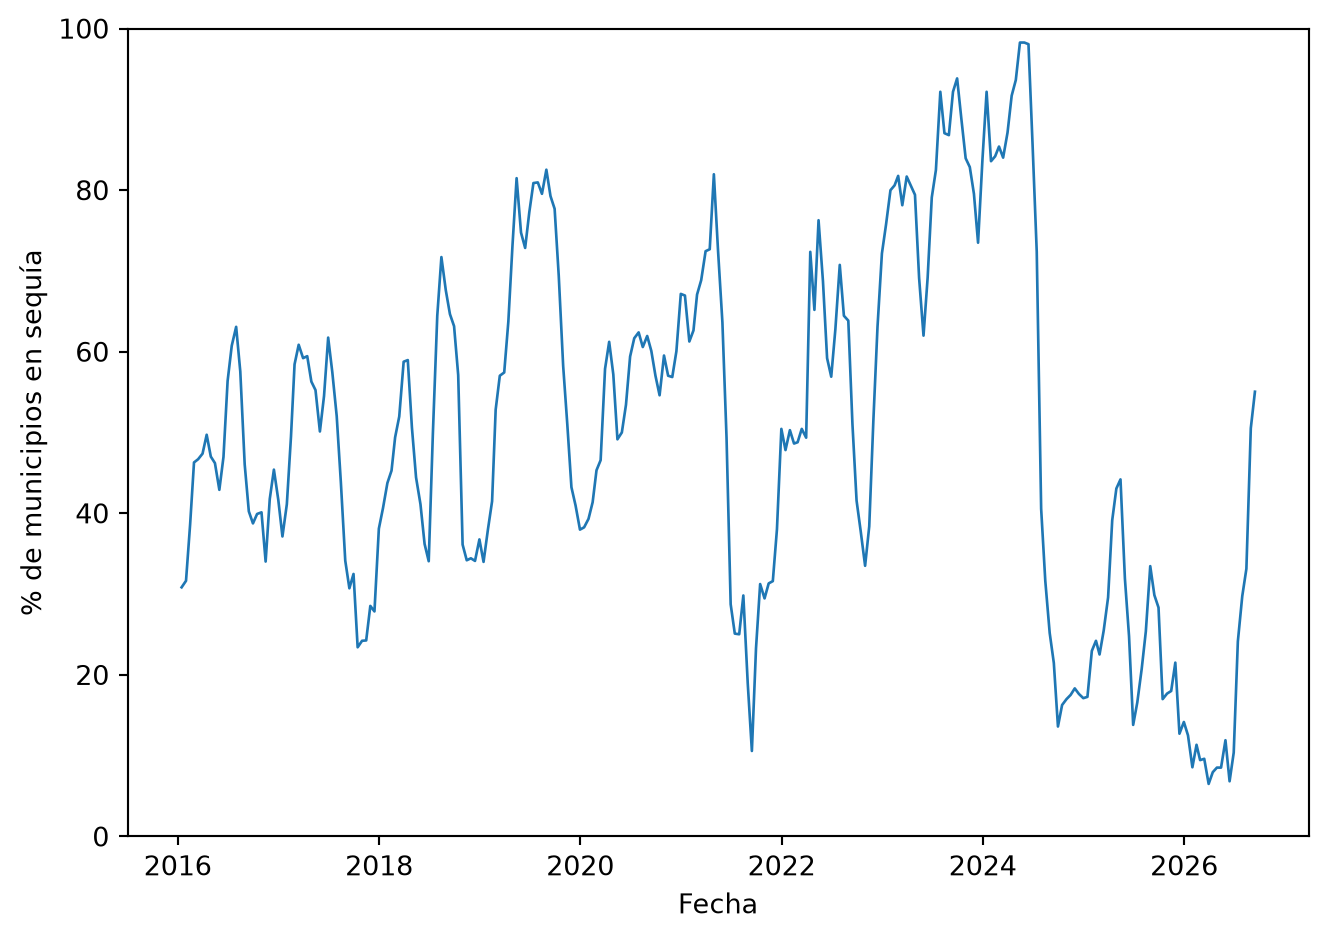

In [12]:
#| label: fig-serie-2016
#| fig-cap: Porcentaje de municipios en sequía (D0+), quincenal, 2016-2026

pct_quincenal = (df_analitico.groupby("fecha")["intensidad"]
                              .apply(lambda s: (s > 0).mean() * 100))

fig, ax = plt.subplots()
ax.plot(pct_quincenal.index, pct_quincenal.values, linewidth=1)
ax.set_xlabel("Fecha")
ax.set_ylabel("% de municipios en sequía")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [13]:
#| label: tbl-distribucion
#| tbl-cap: Distribución de categorías en el dataset analítico (2016+)

display(df_analitico["intensidad_desc"].value_counts().rename("frecuencia").to_frame())

,frecuencia
intensidad_desc,
Sin sequía,318571
D0 Anormalmente seco,163950
D1 Sequía moderada,86342
D2 Sequía severa,41673
D3 Sequía extrema,19248
D4 Sequía excepcional,4584


In [14]:
#| label: guardado

df_historico.to_parquet("../data/processed/sequia_historico.parquet", index=False)
df_analitico.to_parquet("../data/processed/sequia_analitico_2016.parquet", index=False)

print("Archivos guardados en data/processed/")

Archivos guardados en data/processed/
